🎯 Day 6: Logistic Regression Accuracy: 100.00%

📊 Day 7: Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


✅ All Steps Completed! 'random_forest_model.pkl' saved successfully.


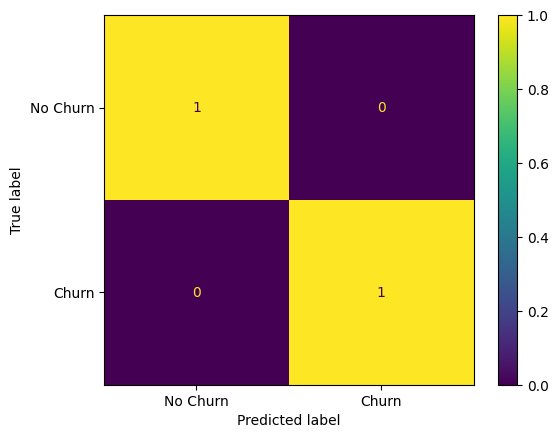

In [3]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Data Generation (Fixing Empty File)
data = {
    'age': [34, 22, 45, 29, 61, 25, 48, 37, 52, 19],
    'monthly_charges': [70.5, 55.0, 95.0, 80.0, 110.5, 45.0, 85.0, 60.0, 100.0, 50.0],
    'tenure_months': [12, 3, 24, 6, 36, 1, 18, 9, 48, 2],
    'internet_Service_Fiber': [1, 0, 1, 1, 1, 0, 1, 0, 1, 0], 
    'internet_Service_DSL': [0, 1, 0, 0, 0, 1, 0, 1, 0, 1],   
    'churn': [0, 1, 0, 1, 0, 1, 0, 0, 0, 1]                    
}
df = pd.DataFrame(data)
df.to_csv("cleaned_data.csv", index=False)

# 2. Target Isolation
y = df['churn']              
X = df.drop(columns=['churn']) 

# 3. Train-Test Split (80/20 Rule)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Day 6: Baseline Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_accuracy = lr_model.score(X_test, y_test)

# 5. Day 7: Ensemble Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# 6. Advanced Evaluation Metrics
print("=======================================================")
print(f"🎯 Day 6: Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print("=======================================================")
print("\n📊 Day 7: Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("=======================================================")

# 7. Visual Confusion Matrix
cm = confusion_matrix(y_test, rf_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot()

# 8. Serialize Model Weights
joblib.dump(rf_model, "random_forest_model.pkl")
print("\n✅ All Steps Completed! 'random_forest_model.pkl' saved successfully.")